In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import scipy.constants as pc
import astropy.units as u
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy.table import Table
from astropy.visualization import AsinhStretch, ImageNormalize, ManualInterval
import os
import shutil

FILTERS =["F606W", "F814W","F115W", "F150W", "F200W", "F277W", "F356W", "F444W"]
# Individual filters increasing in wavelength
# Stacked filters are not useful for Sersíc fitting

CUTOUT_SIZES = ["0.96as", "3.0as"]
# The side lenghts of the plot out squares (each pixel is 0.03 as across) 

BROAD_LINE_DATA_PATH = "/nvme/scratch/work/alberttg/Summer_project/Ha_and_NII_broad_line_data.fits"



In [7]:
def open_table(file_path):
        # Open the FITS file
        with fits.open(file_path) as hdul:
            # Show the HDU structure
            hdul.info()

            # Usually the table is in extension 1
            data = hdul[1].data

        # Convert to an Astropy Table
        tbl = Table(data)

        """
        print("\nColumns:")
        print(tbl.colnames)
        """
        return tbl

In [8]:

def cutout_plot(BROAD_LINE_DATA_PATH):
    """
    This function creates a figure of 8 subplots in a 2x4 grid for each galaxy in the provided FITS table.
    Each subplot corresponds to a different filter, and the cutouts are saved in my own folders.
    """

    table = open_table(BROAD_LINE_DATA_PATH)
    # All my raw data on the galaxies
    
    ids = table["SURVEY_ID"]
    surveys = table["SURVEY"]

    for i in range(len(ids)):

        id = ids[i]
        survey = surveys[i]

        found_cutout = False

        # Create an output directory for this galaxy
        output_dir = f"/nvme/scratch/work/alberttg/Summer_project/Data_products/Cutouts/{id}"
        os.makedirs(output_dir, exist_ok=True)  

        #Creating a figure of 8 subplots in 2x4 grid for each galaxy
        fig, axes = plt.subplots(2,4, figsize=(20,10), constrained_layout=True)
        axes = axes.ravel()
        fig.subplots_adjust(left=0.02,right=0.98,bottom=0.03,top=0.90,wspace=0.03,hspace=0.08)


        for j, filt in enumerate(FILTERS):
            
            ax = axes[j]

            if survey in ["CEERSP1", "CEERSP2", "CEERSP3", "CEERSP4", "CEERSP5", "CEERSP6", "CEERSP7", "CEERSP8", "CEERSP9", "CEERSP10"]:

                    path = f"/raid/scratch/work/austind/GALFIND_WORK/Cutouts/v14/{survey}/ACS_WFC+NIRCam/3.00as/{filt}/data_native/{id}.fits"

            elif survey in ["PRIMER-COSMOS","PRIMER-UDS"]:
                  
                    path = f"/raid/scratch/work/austind/GALFIND_WORK/Cutouts/v12/{survey}/ACS_WFC+NIRCam/3.00as/{filt}/data_native/{id}.fits"


            elif survey in ["JADES-DR3-GS-East", "JADES-DR3-GS-North", "JADES-DR3-GS-South", "JADES-DR3-GS-West", "JADES-DR3-GN-Parallel", "JADES-DR3-GN-Medium", "JADES-DR3-GN-Deep"]:

                    path = f"/raid/scratch/work/austind/GALFIND_WORK/Cutouts/v13/{survey}/ACS_WFC+NIRCam/3.00as/{filt}/data_native/{id}.fits"
            else:
                    print(f"Galaxy {id} could not be found in these surveys")
                    print(f"Check survey {survey}")
                    break
            
            # Skip this filter if the FITS file doesn't exist
            if not os.path.exists(path):
                print(f"Missing {filt} cutout for galaxy {id}")
                print(path)
                ax.text(0.5, 0.5, f"{filt}\nMissing", ha="center", va="center", transform=ax.transAxes, fontsize=10)
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            # Copy the complete FITS file (all HDUs/extensions)
            output_fits = os.path.join(output_dir, f"{filt}.fits")

            # Only copy if it isn't already there
            if not os.path.exists(output_fits):
                shutil.copy2(path, output_fits)

            
            # Making the plot of the cutout for this filter
            with fits.open(path) as hdul:
                        data = hdul[1].data #science image
                        seg = hdul[2].data
            
            found_cutout = True

            vmin, vmax = np.percentile(data, (5,99))
            # Maybe change for visualisation

            norm = ImageNormalize(data, interval=ManualInterval(vmin=vmin, vmax=vmax), # automatic contrast (like DS9)
                                  stretch=AsinhStretch())                      
            # Asinh keeps faint structures but becomes log at high flux to show structural differences at centre
            ax.imshow(data, norm=norm, origin="lower", cmap="gray")
            
            # label filt in upper right
            # (0,0) is bottom left
            # (1,1) is top right
            ax.text(0.98, 0.98, f"{filt}", transform=ax.transAxes, ha="right", va="top", fontsize=15, bbox=dict(boxstyle="round,pad=0.3",facecolor="white",edgecolor="black",alpha=0.9))
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_aspect("equal")
            # Removes tick marks
        plt.tight_layout()
        #plt.show()
        plt.savefig(os.path.join(output_dir, f"{id}_cutouts.png"), dpi=300, bbox_inches="tight", facecolor="black")
        plt.close(fig)


    """
        if not found_cutout:
              missing_galaxies.append((survey, id, table["ALPHA_J2000"][i], table["DELTA_J2000"][i]))

    missing_table = Table(
        rows=missing_galaxies,
        names=("SURVEY", "SURVEY_ID", "ALPHA_J2000", "DELTA_J2000")
        )

    missing_table.write("/nvme/scratch/work/alberttg/Summer_project/missing_cutouts.csv",format="csv",overwrite=True)
    print(f"{len(missing_table)} galaxies had no cutouts.")

    """

In [9]:
def copy_psf_data(BROAD_LINE_DATA_PATH):

    table = open_table(BROAD_LINE_DATA_PATH)
    # All my raw data on the galaxies
    
    surveys = table["SURVEY"]

    for survey in surveys:

        output_dir = f"/nvme/scratch/work/alberttg/Summer_project/Data_products/PSFs/{survey}"
        os.makedirs(output_dir, exist_ok=True)  

        for filt in ["F115W", "F150W", "F200W", "F277W", "F356W", "F444W"]:
            #NIRCam data

            if survey in ["CEERSP1", "CEERSP2", "CEERSP3", "CEERSP4", "CEERSP5", "CEERSP6", "CEERSP7", "CEERSP8", "CEERSP9", "CEERSP10"]:

                    path = f"/raid/scratch/work/austind/GALFIND_WORK/PSFs/NIRCam/v14/{survey}/{filt}/empirical/pixscl=0.03as_size=4.0as_galfind.fits"
                    # Duncan is missing F606W, F814W in NIRCam

            elif survey in ["PRIMER-COSMOS","PRIMER-UDS"]:
                  
                    path = f"/raid/scratch/work/austind/GALFIND_WORK/PSFs/NIRCam/v12/{survey}/{filt}/empirical/pixscl=0.03as_size=4.0as_galfind.fits"


            elif survey in ["JADES-DR3-GS-East", "JADES-DR3-GS-North", "JADES-DR3-GS-South", "JADES-DR3-GS-West", "JADES-DR3-GN-Parallel", "JADES-DR3-GN-Medium", "JADES-DR3-GN-Deep"]:

                    path = f"/raid/scratch/work/austind/GALFIND_WORK/PSFs/NIRCam/v13/{survey}/{filt}/empirical/pixscl=0.03as_size=4.0as_galfind.fits"

            else:
                    print(f"Could not find {path}")
                    break

            # Copy the complete FITS file (all HDUs/extensions)
            output_fits = os.path.join(output_dir, f"{filt}_psf_norm.fits")

            # Only copy if it isn't already there
            if not os.path.exists(output_fits):
                shutil.copy2(path, output_fits)

        for filt in ["F606W", "F814W"]:
              # ACS_WFC data
            if survey in ["CEERSP1", "CEERSP2", "CEERSP3", "CEERSP4", "CEERSP5", "CEERSP6", "CEERSP7", "CEERSP8", "CEERSP9", "CEERSP10"]:

                    path = f"/raid/scratch/work/austind/GALFIND_WORK/PSFs/ACS_WFC/v14/{survey}/{filt}/empirical/pixscl=0.03as_size=4.0as_galfind.fits"
                    # Duncan is missing F606W, F814W in NIRCam

            elif survey in ["PRIMER-COSMOS","PRIMER-UDS"]:
                  
                    path = f"/raid/scratch/work/austind/GALFIND_WORK/PSFs/ACS_WFC/v12/{survey}/{filt}/empirical/pixscl=0.03as_size=4.0as_galfind.fits"


            elif survey in ["JADES-DR3-GS-East", "JADES-DR3-GS-North", "JADES-DR3-GS-South", "JADES-DR3-GS-West", "JADES-DR3-GN-Parallel", "JADES-DR3-GN-Medium", "JADES-DR3-GN-Deep"]:

                    path = f"/raid/scratch/work/austind/GALFIND_WORK/PSFs/ACS_WFC/v13/{survey}/{filt}/empirical/pixscl=0.03as_size=4.0as_galfind.fits"

            else:
                    print(f"Could not find {path}")
                    break

            # Copy the complete FITS file (all HDUs/extensions)
            output_fits = os.path.join(output_dir, f"{filt}_psf_norm.fits")

            # Only copy if it isn't already there
            if not os.path.exists(output_fits):
                shutil.copy2(path, output_fits)
        

Filename: /nvme/scratch/work/alberttg/Summer_project/Ha_and_NII_broad_line_data.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    168   144R x 80C   [D, E, E, E, E, E, E, E, E, 5A, D, D, D, E, E, E, E, E, E, E, E, D, 55A, D, D, D, D, D, D, D, D, E, E, E, E, E, E, E, E, D, D, D, D, D, D, D, D, E, E, E, E, E, E, E, E, D, D, D, D, D, D, 18A, K, 21A, J, E, E, E, E, E, E, E, E, D, D, D, D, D, D, D]   


/tmp/ipykernel_75233/2378474394.py:27: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(left=0.02,right=0.98,bottom=0.03,top=0.90,wspace=0.03,hspace=0.08)
/tmp/ipykernel_75233/2378474394.py:91: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


KeyboardInterrupt: 

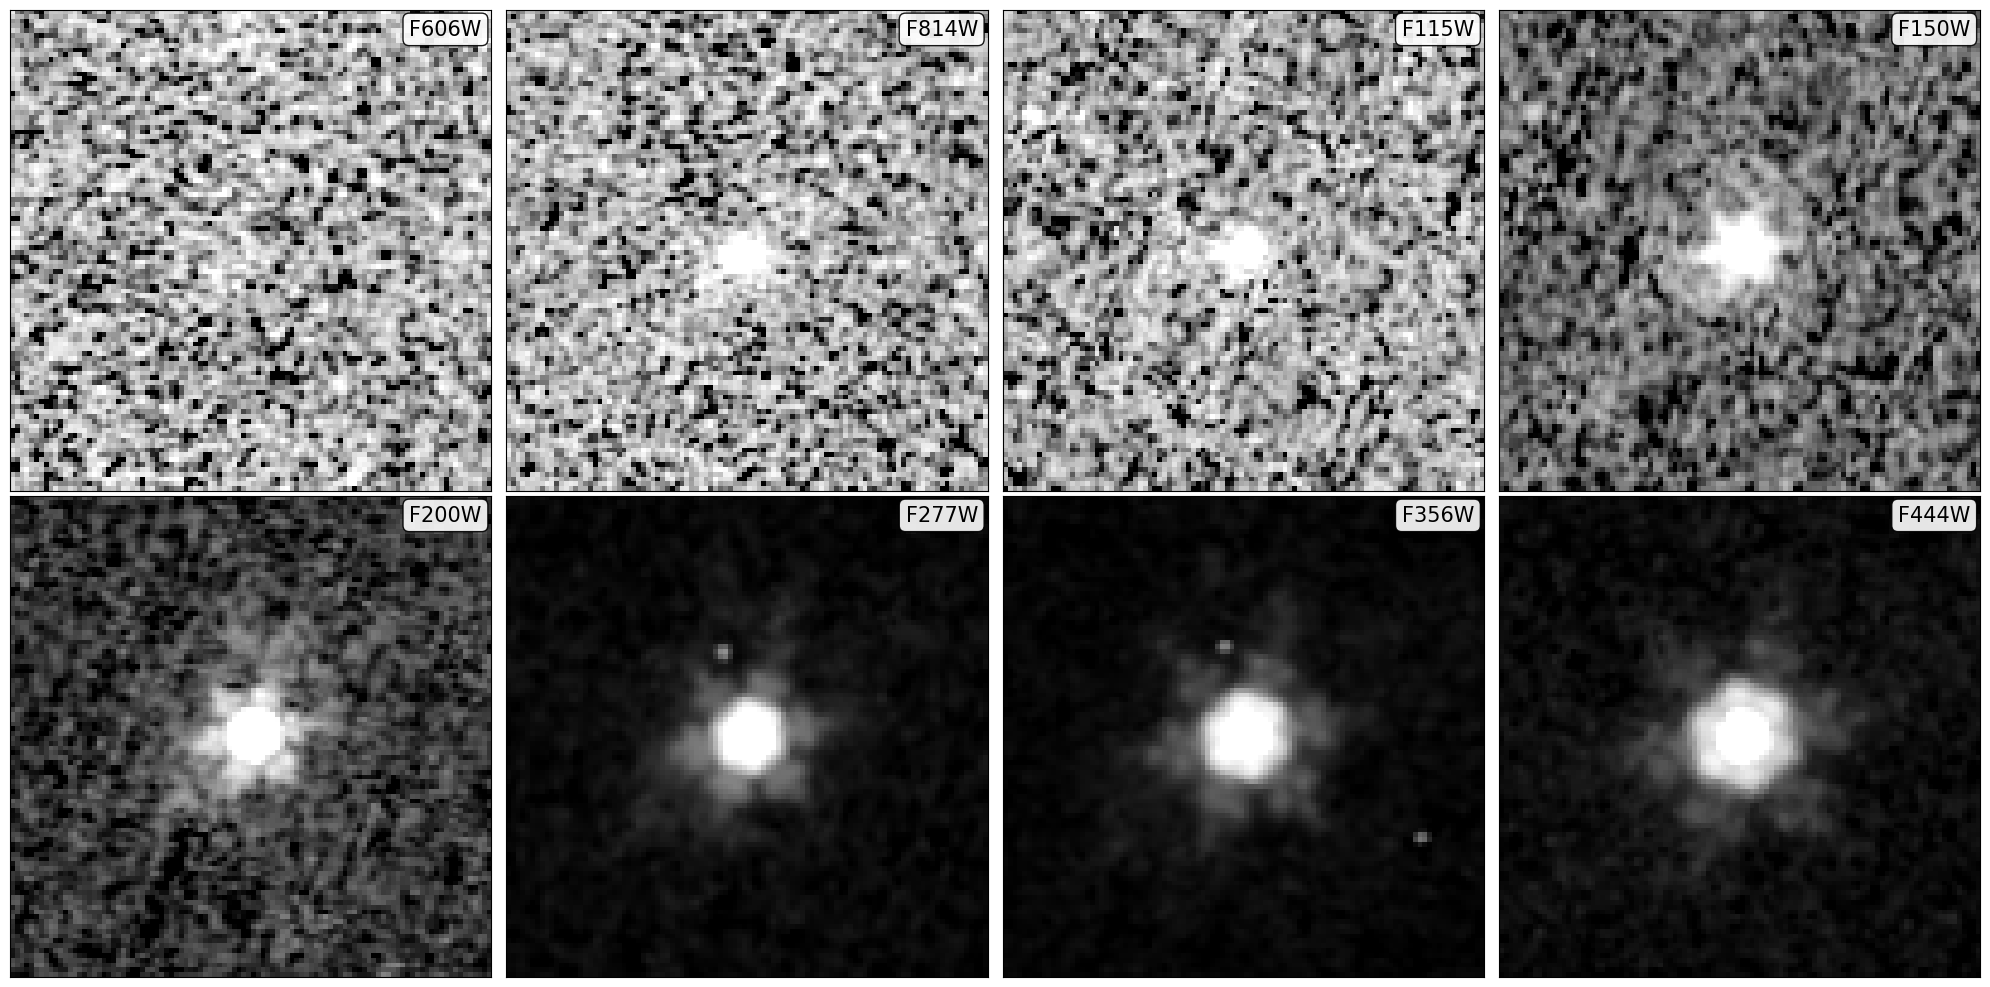

In [11]:
if __name__ == "__main__":

    cutout_plot(BROAD_LINE_DATA_PATH)

    # copy_psf_data(BROAD_LINE_DATA_PATH)

    

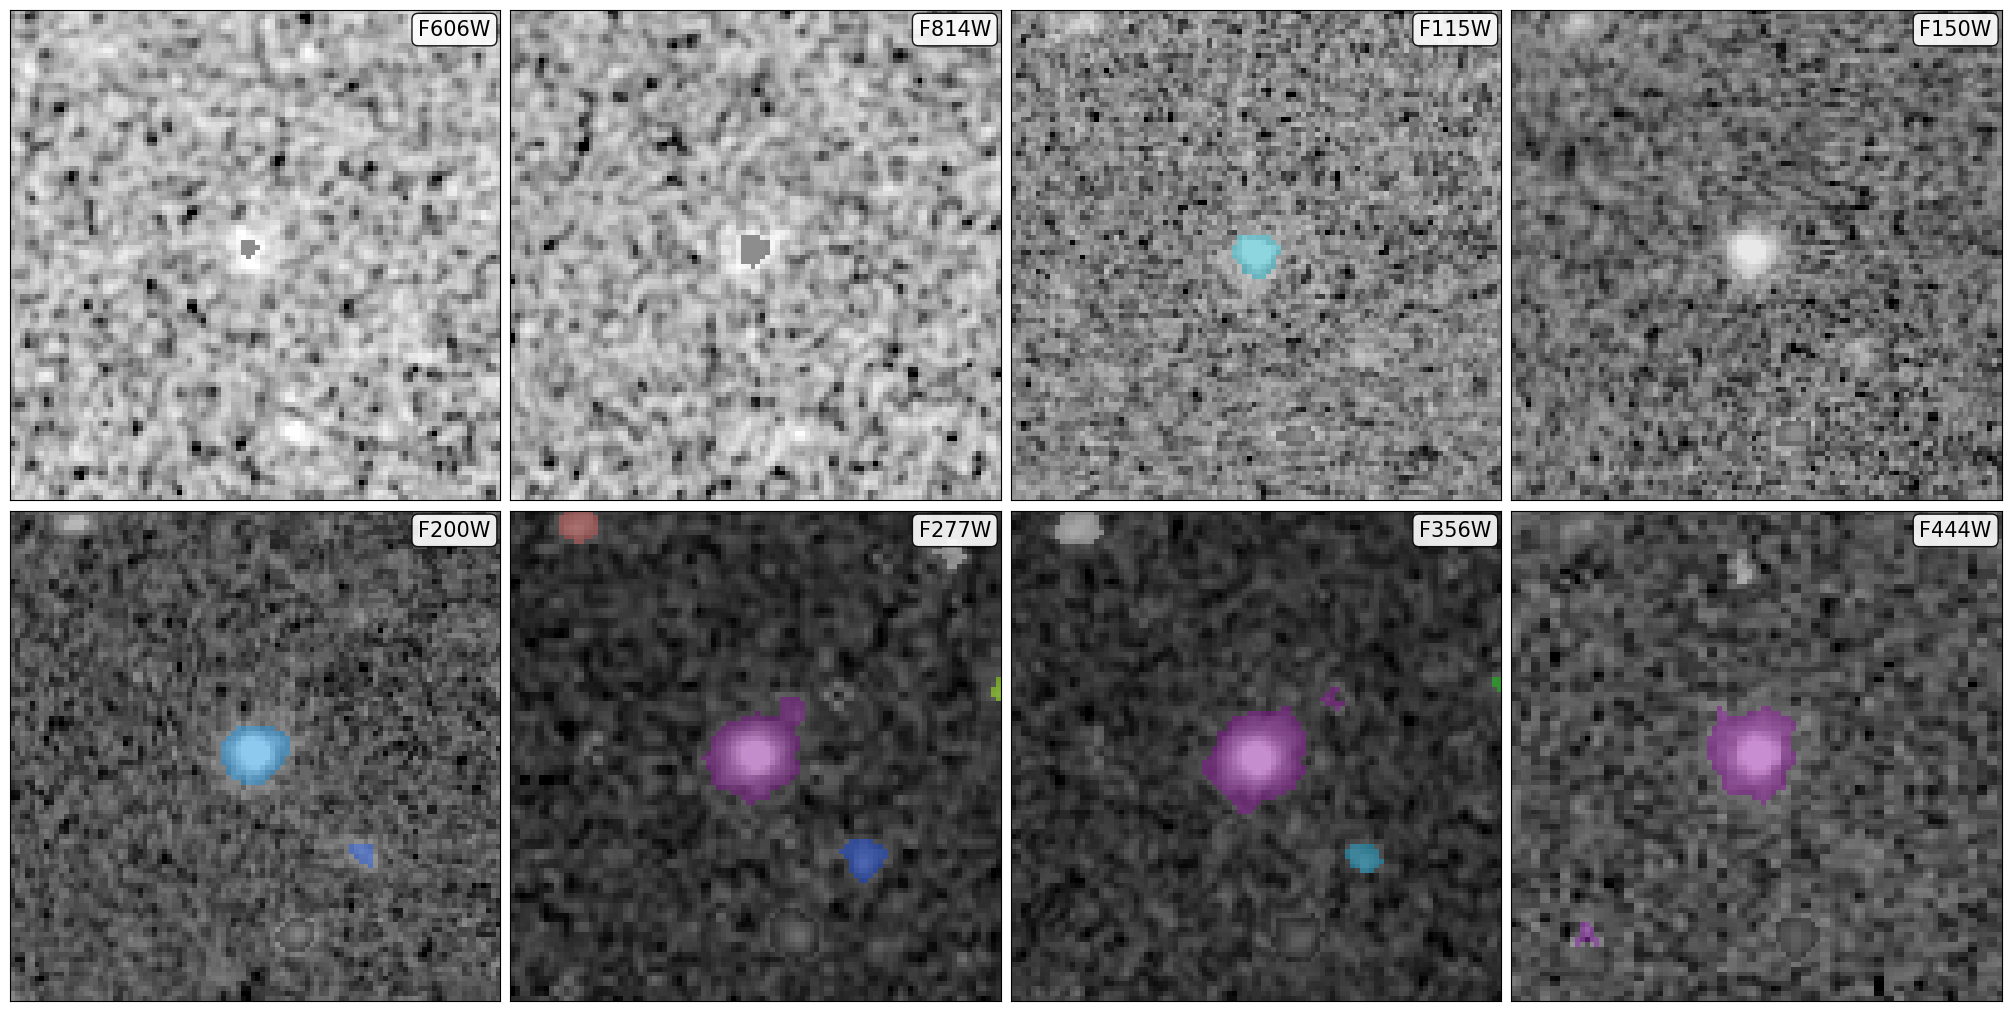

In [8]:

from astropy.io import fits
from astropy.visualization import ImageNormalize, PercentileInterval, AsinhStretch
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 4, figsize=(20, 10), constrained_layout=True)
axes = axes.ravel()

filters = ["F606W", "F814W", "F115W", "F150W",
           "F200W", "F277W", "F356W", "F444W"]

for j, ax in enumerate(axes):

    path = f"/raid/scratch/work/austind/GALFIND_WORK/Cutouts/v14/CEERSP2/ACS_WFC+NIRCam/3.00as/{filters[j]}/data_native/4573.fits"

    with fits.open(path) as hdul:
        sci = hdul[1].data      # science image
        seg = hdul[2].data      # segmentation map

    # Science image scaling
    norm = ImageNormalize(
        sci,
        interval=PercentileInterval(99.5),
        stretch=AsinhStretch()
    )

    # Plot science image
    ax.imshow(sci,
              origin="lower",
              cmap="gray",
              norm=norm)

    # Mask background (ID = 0)
    seg_masked = np.ma.masked_where(seg == 0, seg)

    # Overlay segmentation
    ax.imshow(seg_masked,
              origin="lower",
              cmap="nipy_spectral",
              alpha=0.45,
              interpolation="nearest")

    ax.text(
        0.98, 0.98, filters[j],
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=15,
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="white",
                  edgecolor="black",
                  alpha=0.9)
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")

plt.show()
